In [1]:
import os
import numpy as np
import pandas as pd
import time
import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)
from sklearn.decomposition import PCA
import joblib
import streamlit as st
import warnings
warnings.filterwarnings('ignore')

In [2]:
# --------------------------- Data Loading & Preprocessing ---------------------------
def load_and_preprocess(file_path, sample_frac=0.04, random_state=42):
    """
    Load the NF-ToN-IoT dataset.
    Returns:
      X_scaled, y_enc, feature_names, original_df, encoders, scaler, label_encoder, total_rows, used_rows, pct_used
    """
    print(f"Loading dataset from {file_path} ...")
    # file_path may be a file-like object (Streamlit upload) or a path string
    if hasattr(file_path, "read"):
        df_full = pd.read_csv(file_path)
    else:
        df_full = pd.read_csv(str(file_path))

    total_rows = len(df_full)
    print(f"Total rows in dataset: {total_rows}")

    # sample
    if 0 < sample_frac < 1:
        df = df_full.sample(frac=sample_frac, random_state=random_state).reset_index(drop=True)
    else:
        df = df_full.copy().reset_index(drop=True)

    used_rows = len(df)
    pct_used = (used_rows / total_rows) * 100.0
    print(f"Using {used_rows} rows ({pct_used:.4f}% of the original dataset)")

    # Basic cleaning: drop fully-constant columns
    nunique = df.nunique()
    const_cols = nunique[nunique <= 1].index.tolist()
    if const_cols:
        print("Dropping constant cols:", const_cols)
        df.drop(columns=const_cols, inplace=True)

    # Drop columns with >50% missing values
    miss_pct = df.isna().mean()
    drop_missing = miss_pct[miss_pct > 0.5].index.tolist()
    if drop_missing:
        print("Dropping high-missing cols:", drop_missing)
        df.drop(columns=drop_missing, inplace=True)

    # Drop rows with any remaining missing values
    df.dropna(inplace=True)
    df = df.reset_index(drop=True)

    # Identify label column: common names or last column
    label_candidates = ['attack', 'Attack', 'Label', 'label', 'type']
    label_col = None
    for c in label_candidates:
        if c in df.columns:
            label_col = c
            break
    if label_col is None:
        label_col = df.columns[-1]
        print(f"No standard label column found; using last column '{label_col}' as label")

    y_raw = df[label_col].astype(str).values
    X_df = df.drop(columns=[label_col])
    feature_names = list(X_df.columns)

    # Encode categorical features in X
    encoders = {}
    for col in X_df.select_dtypes(include=['object', 'category']).columns:
        le = LabelEncoder()
        X_df[col] = le.fit_transform(X_df[col].astype(str))
        encoders[col] = le

    X = X_df.values.astype(float)

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Encode target labels and keep mapping
    label_encoder = LabelEncoder()
    y_enc = label_encoder.fit_transform(y_raw)
    print(f"Detected classes ({len(label_encoder.classes_)}): {list(label_encoder.classes_)}")

    return X_scaled, y_enc, feature_names, df, encoders, scaler, label_encoder, total_rows, used_rows, pct_used


In [3]:
# --------------------------- MBGWO ---------------------------
class MBGWO:
    def __init__(self, n_features, pop_size=25, max_iters=50, alpha_w=0.9,
                 random_state=None, subsample_ratio=1.0):
        """
        n_features: dimension
        pop_size: wolves
        max_iters: iterations
        alpha_w: weight for F1 vs feature-count penalty (0..1)
        subsample_ratio: fraction of training set to use for fitness to speed up (<=1.0)
        """
        self.n_features = n_features
        self.pop_size = pop_size
        self.max_iters = max_iters
        self.alpha_w = alpha_w
        self.random_state = random_state
        if random_state is not None:
            np.random.seed(random_state)

        self.subsample_ratio = subsample_ratio

        self.alpha_pos = None; self.alpha_score = -np.inf
        self.beta_pos = None;  self.beta_score = -np.inf
        self.delta_pos = None; self.delta_score = -np.inf

        self.history = []

    def _sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-x))

    def _init_population(self):
        # continuous positions that will be passed through sigmoid then Bernoulli
        return np.random.uniform(-6, 6, size=(self.pop_size, self.n_features))

    def _binarize(self, pos):
        prob = self._sigmoid(pos)
        return (np.random.rand(*prob.shape) < prob).astype(int)

    def _fitness(self, binary_mask, X_train, X_val, y_train, y_val):
        """Use RandomForest for fitness evaluation (fast)."""
        if binary_mask.sum() == 0:
            return -1.0

        idx = np.where(binary_mask == 1)[0]
        Xtr = X_train[:, idx]
        Xvl = X_val[:, idx]

        if self.subsample_ratio < 1.0:
            subsample_size = max(10, int(len(Xtr) * self.subsample_ratio))
            subsample_idx = np.random.choice(len(Xtr), subsample_size, replace=False)
            Xtr_sub = Xtr[subsample_idx]
            ytr_sub = y_train[subsample_idx]
        else:
            Xtr_sub, ytr_sub = Xtr, y_train

        clf = RandomForestClassifier(
            n_estimators=50,
            class_weight='balanced',
            random_state=self.random_state,
            n_jobs=-1
        )
        clf.fit(Xtr_sub, ytr_sub)
        ypred = clf.predict(Xvl)
        f1 = f1_score(y_val, ypred, average='weighted', zero_division=0)
        size_ratio = idx.size / float(self.n_features)
        # The higher fitness the better
        return self.alpha_w * f1 + (1.0 - self.alpha_w) * (1.0 - size_ratio)

    def run(self, X, y, test_size=0.3, random_state=42, patience=5):
        """Main MBGWO loop. Returns (best_binary_mask, history)"""
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=random_state
        )
        pos = self._init_population()
        bin_pos = self._binarize(pos)

        # initial evaluation
        scores = np.array([self._fitness(bin_pos[i], X_train, X_val, y_train, y_val)
                           for i in range(self.pop_size)])
        idx_sorted = np.argsort(scores)[::-1]
        self.alpha_pos = pos[idx_sorted[0]].copy(); self.alpha_score = scores[idx_sorted[0]]
        self.beta_pos  = pos[idx_sorted[1]].copy(); self.beta_score  = scores[idx_sorted[1]]
        self.delta_pos = pos[idx_sorted[2]].copy(); self.delta_score = scores[idx_sorted[2]]

        no_improve = 0

        for t in range(self.max_iters):
            scores = np.zeros(self.pop_size)
            for i in range(self.pop_size):
                scores[i] = self._fitness(self._binarize(pos[i]), X_train, X_val, y_train, y_val)

            idx_sorted = np.argsort(scores)[::-1]
            best_now = scores[idx_sorted[0]]

            # update alpha/beta/delta if improved
            if best_now > self.alpha_score:
                self.alpha_score = best_now
                self.alpha_pos = pos[idx_sorted[0]].copy()
                improved = True
                no_improve = 0
            else:
                improved = False
                no_improve += 1

            if scores[idx_sorted[1]] > self.beta_score:
                self.beta_score = scores[idx_sorted[1]]
                self.beta_pos = pos[idx_sorted[1]].copy()
            if scores[idx_sorted[2]] > self.delta_score:
                self.delta_score = scores[idx_sorted[2]]
                self.delta_pos = pos[idx_sorted[2]].copy()

            selected = int(self._binarize(self.alpha_pos).sum())
            self.history.append({
                'iter': t+1,
                'best_score': float(self.alpha_score),
                'selected_count': selected
            })

            print(f"Iter {t+1}/{self.max_iters} | best {self.alpha_score:.4f} | sel {selected}/{self.n_features}")

            if no_improve >= patience:
                print(f"Early stopping at iter {t+1} (no improv for {patience} iters)")
                break

            # update positions
            a = 2 - (t * (2.0 / max(1, self.max_iters)))
            for i in range(self.pop_size):
                r1 = np.random.rand(self.n_features); r2 = np.random.rand(self.n_features)
                A1 = 2 * a * r1 - a; C1 = 2 * r2
                D1 = np.abs(C1 * self.alpha_pos - pos[i])
                X1 = self.alpha_pos - A1 * D1

                r1 = np.random.rand(self.n_features); r2 = np.random.rand(self.n_features)
                A2 = 2 * a * r1 - a; C2 = 2 * r2
                D2 = np.abs(C2 * self.beta_pos - pos[i])
                X2 = self.beta_pos - A2 * D2

                r1 = np.random.rand(self.n_features); r2 = np.random.rand(self.n_features)
                A3 = 2 * a * r1 - a; C3 = 2 * r2
                D3 = np.abs(C3 * self.delta_pos - pos[i])
                X3 = self.delta_pos - A3 * D3

                pos[i] = (X1 + X2 + X3) / 3.0

        # final mask from alpha_pos
        best_mask = self._binarize(self.alpha_pos)
        return best_mask, self.history

In [4]:
def evaluate_models_on_selected(X_train, X_test, y_train, y_test, selected_mask):
    if selected_mask is None or selected_mask.sum() == 0:
        print("Warning: no features selected — using all features for evaluation")
        sel_idx = np.arange(X_train.shape[1])
    else:
        sel_idx = np.where(selected_mask == 1)[0]

    Xtr = X_train[:, sel_idx]
    Xte = X_test[:, sel_idx]

    max_samples = 40000
    if len(Xtr) > max_samples:
        X_svm, _, y_svm, _ = train_test_split(
            Xtr, y_train, train_size=max_samples, stratify=y_train, random_state=42
        )
    else:
        X_svm, y_svm = Xtr, y_train

    # Fix here: dynamic PCA components
    n_features_selected = X_svm.shape[1]
    n_samples_svm = X_svm.shape[0]
    n_components = min(20, n_features_selected, n_samples_svm)
    
    print(f"Applying PCA with n_components={n_components} on data with shape {X_svm.shape}")

    pca = PCA(n_components=n_components, random_state=42)
    X_svm_pca = pca.fit_transform(X_svm)
    Xte_pca = pca.transform(Xte)

    svm = SVC(kernel='rbf', gamma='scale', class_weight='balanced', probability=True, random_state=42)
    print(f"Training SVM on {X_svm_pca.shape[0]} samples and {X_svm_pca.shape[1]} PCA components...")
    svm.fit(X_svm_pca, y_svm)
    ypred_svm = svm.predict(Xte_pca)

    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)
    rf.fit(Xtr, y_train)
    ypred_rf = rf.predict(Xte)

    def compute_metrics(y_true, y_pred):
        return {
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
            'recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
            'f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
            'classification_report': classification_report(y_true, y_pred, zero_division=0, output_dict=True)
        }

    metrics_svm = compute_metrics(y_test, ypred_svm)
    metrics_rf = compute_metrics(y_test, ypred_rf)

    return {
        'sel_idx': sel_idx,
        'svm': {'model': svm, 'ypred': ypred_svm, 'metrics': metrics_svm},
        'rf':  {'model': rf,  'ypred': ypred_rf,  'metrics': metrics_rf}
    }


In [5]:
# --------------------------- Plotting helpers ---------------------------
def show_confusion_plot(cm, classes, normalize=False):
    plt.figure(figsize=(6,5))
    if normalize:
        cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)
        plt.imshow(cm_norm, interpolation='nearest')
        plt.title('Confusion matrix (normalized)')
    else:
        plt.imshow(cm, interpolation='nearest')
        plt.title('Confusion matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [11]:
# --------------------------- Main script for running locally (non-streamlit) ---------------------------
if __name__ == "__main__" and "streamlit" not in os.environ.get("RUN_BY_STREAMLIT", ""):
    print('='*60)
    print('MBGWO Feature Selection')
    print('Date:', datetime.datetime.now())
    print('='*60)

    # Adjust path and sample fraction as needed
    file_path = 'Downloads/NF-ToN-IoT-v3.csv'  # update path
    sample_frac = 0.04
    random_state = 42

    X, y, feature_names, original_df, encoders, scaler, label_encoder, total_rows, used_rows, pct_used = load_and_preprocess(file_path, sample_frac=sample_frac, random_state=random_state)

    X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X, y, test_size=0.2, stratify=y, random_state=random_state)

    mbgwo = MBGWO(
        n_features=X.shape[1],
        pop_size=25,
        max_iters=50,
        alpha_w=0.9,
        random_state=42,
        subsample_ratio=1.0
    )

    selected_mask, history = mbgwo.run(X_train_full, y_train_full, test_size=0.25, patience=3)

    for h in history:
        print(f"Iter {h['iter']:02d} | Best {h['best_score']:.4f} | Sel {h['selected_count']}")

    sel_idx = np.where(selected_mask == 1)[0]
    print(f"\nFinal selected features: {len(sel_idx)} / {X.shape[1]} ({(len(sel_idx)/X.shape[1])*100:.2f}%)")
    if len(sel_idx) > 0:
        print("Selected features (names):")
        for i in sel_idx:
            print(" -", feature_names[i])
    else:
        print("No features selected — using all features.")

MBGWO Feature Selection
Date: 2025-12-07 18:40:30.939272
Loading dataset from Downloads/NF-ToN-IoT-v3.csv ...
Total rows in dataset: 27520260
Using 1100810 rows (4.0000% of the original dataset)
Detected classes (10): ['Backdoor', 'Benign', 'ddos', 'dos', 'injection', 'mitm', 'password', 'ransomware', 'scanning', 'xss']
Iter 1/50 | best 0.9666 | sel 23/54
Iter 2/50 | best 0.9666 | sel 19/54
Iter 3/50 | best 0.9685 | sel 21/54
Iter 4/50 | best 0.9703 | sel 17/54
Iter 5/50 | best 0.9703 | sel 15/54
Iter 6/50 | best 0.9722 | sel 15/54
Iter 7/50 | best 0.9741 | sel 17/54
Iter 8/50 | best 0.9741 | sel 19/54
Iter 9/50 | best 0.9741 | sel 19/54
Iter 10/50 | best 0.9741 | sel 18/54
Early stopping at iter 10 (no improv for 3 iters)
Iter 01 | Best 0.9666 | Sel 23
Iter 02 | Best 0.9666 | Sel 19
Iter 03 | Best 0.9685 | Sel 21
Iter 04 | Best 0.9703 | Sel 17
Iter 05 | Best 0.9703 | Sel 15
Iter 06 | Best 0.9722 | Sel 15
Iter 07 | Best 0.9741 | Sel 17
Iter 08 | Best 0.9741 | Sel 19
Iter 09 | Best 0.97

In [13]:
# Evaluate on hold-out test set
eval_results = evaluate_models_on_selected(X_train_full, X_test_full, y_train_full, y_test_full, selected_mask)
    
# Print clean classification reports
print("\nSVM Classification Report:")
svm_report_df = pd.DataFrame(eval_results['svm']['metrics']['classification_report']).transpose()
print(svm_report_df[['precision', 'recall', 'f1-score', 'support']])

print("\nRandom Forest Classification Report:")
rf_report_df = pd.DataFrame(eval_results['rf']['metrics']['classification_report']).transpose()
print(rf_report_df[['precision', 'recall', 'f1-score', 'support']])

Applying PCA with n_components=18 on data with shape (40000, 18)
Training SVM on 40000 samples and 18 PCA components...

SVM Classification Report:
              precision    recall  f1-score        support
0              0.995172  0.999394  0.997279    1650.000000
1              0.998982  0.999866  0.999424  134467.000000
2              0.999051  0.989274  0.994139   33003.000000
3              0.954491  0.995628  0.974625    1601.000000
4              0.909258  0.969281  0.938311    3060.000000
5              0.970588  0.733333  0.835443      45.000000
6              0.983764  0.975232  0.979480   12799.000000
7              0.600000  0.454545  0.517241      33.000000
8              0.999723  0.999078  0.999401   10849.000000
9              0.986486  0.989230  0.987856   22655.000000
accuracy       0.995117  0.995117  0.995117       0.995117
macro avg      0.939752  0.910486  0.922320  220162.000000
weighted avg   0.995194  0.995117  0.995129  220162.000000

Random Forest Classificat

In [14]:
 # Save artifacts
os.makedirs('artifacts', exist_ok=True)
joblib.dump(mbgwo, 'artifacts/mbgwo_model.joblib')
joblib.dump(eval_results['svm']['model'], 'artifacts/svm_model.joblib')
joblib.dump(eval_results['rf']['model'], 'artifacts/rf_model.joblib')
np.save('artifacts/selected_mask.npy', selected_mask)
joblib.dump(label_encoder, 'artifacts/label_encoder.joblib')
joblib.dump(encoders, 'artifacts/feature_encoders.joblib')
joblib.dump(scaler, 'artifacts/scaler.joblib')
joblib.dump(feature_names, 'artifacts/feature_names.joblib')
pd.DataFrame(history).to_csv('artifacts/mbgwo_history.csv', index=False)
print("Saved artifacts to ./artifacts/")

Saved artifacts to ./artifacts/


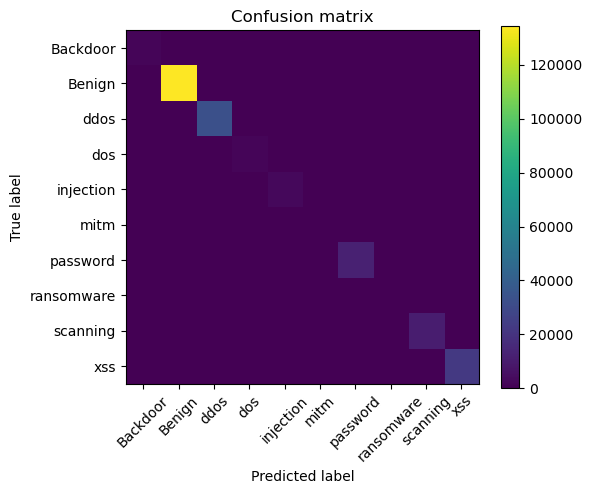

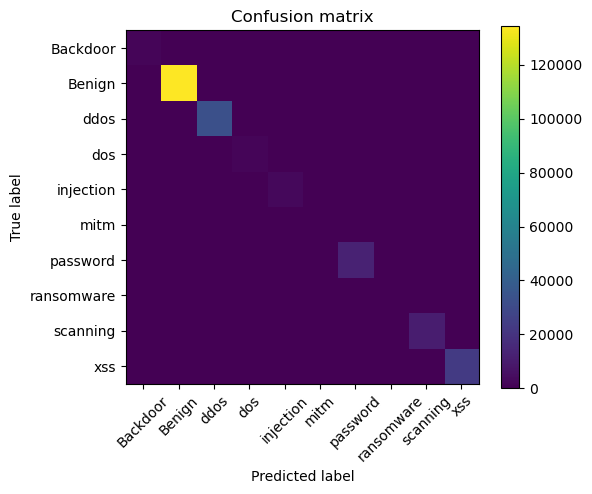

In [24]:
classes = label_encoder.classes_
svm_cm = confusion_matrix(y_test_full, eval_results['svm']['ypred'])
rf_cm  = confusion_matrix(y_test_full, eval_results['rf']['ypred'])

show_confusion_plot(svm_cm, classes, normalize=False)
show_confusion_plot(rf_cm, classes, normalize=False)

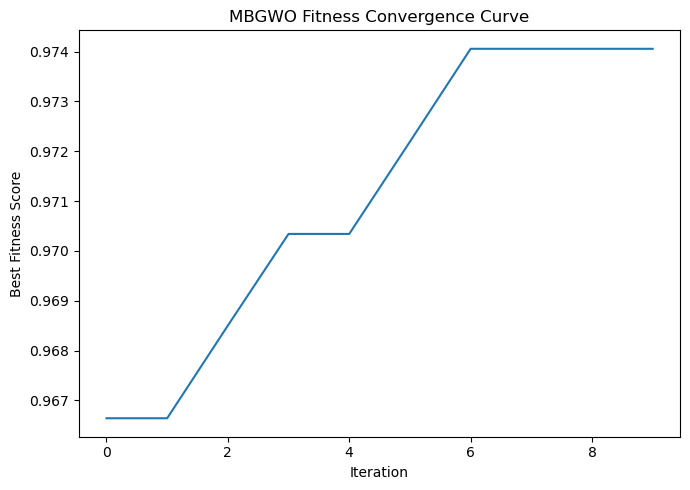

In [28]:
fitness_curve = [h['best_score'] for h in history]

plt.figure(figsize=(7,5))
plt.plot(fitness_curve)
plt.title("MBGWO Fitness Convergence Curve")
plt.xlabel("Iteration")
plt.ylabel("Best Fitness Score")
plt.tight_layout()
plt.show()

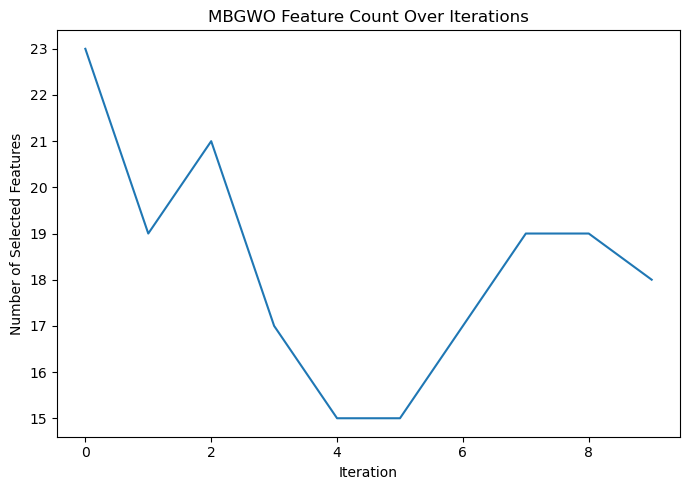

In [30]:
feature_count_curve = [h['selected_count'] for h in history]

plt.figure(figsize=(7,5))
plt.plot(feature_count_curve)
plt.title("MBGWO Feature Count Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Number of Selected Features")
plt.tight_layout()
plt.show()

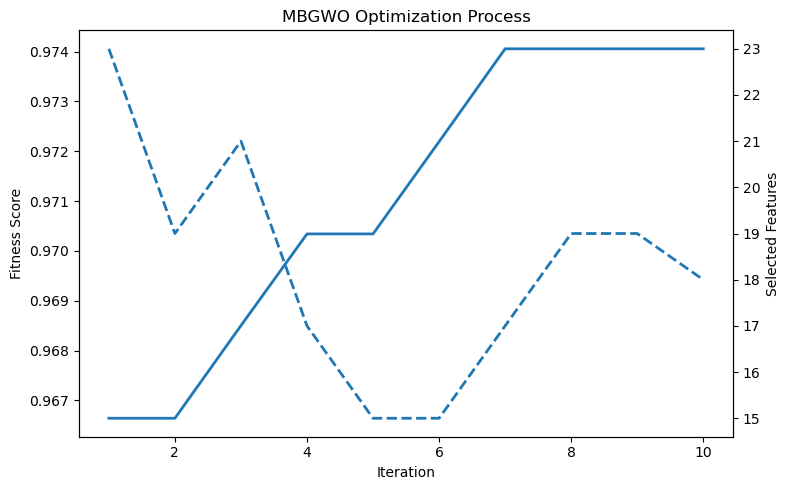

In [32]:
iters = [h['iter'] for h in history]
fitness = [h['best_score'] for h in history]
feat_count = [h['selected_count'] for h in history]

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Fitness Score')
ax1.plot(iters, fitness, label='Fitness', linewidth=2)
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.set_ylabel('Selected Features')
ax2.plot(iters, feat_count, '--', label='Selected Features', linewidth=2)

plt.title("MBGWO Optimization Process")
fig.tight_layout()
plt.show()

In [11]:
svm = joblib.load('artifacts/svm_model.joblib')
rf = joblib.load('artifacts/rf_model.joblib')
selected_mask = np.load('artifacts/selected_mask.npy')
scaler = joblib.load('artifacts/scaler.joblib')
encoders = joblib.load('artifacts/feature_encoders.joblib')
label_encoder = joblib.load('artifacts/label_encoder.joblib')
feature_names = joblib.load('artifacts/feature_names.joblib')

print("\n========== ARTIFACT LOAD STATUS ==========")
print("✓ SVM model loaded")
print("✓ Random Forest model loaded")
print(f"✓ Selected feature mask loaded ({selected_mask.sum()} selected out of {len(selected_mask)})")
print("✓ Scaler loaded")
print(f"✓ Encoders loaded for {len(encoders)} categorical columns")
print("✓ Label encoder loaded")
print(f"✓ Feature names loaded ({len(feature_names)} total features)")
print("===========================================\n")



========== ARTIFACT LOAD STATUS ==========
✓ SVM model loaded
✓ Random Forest model loaded
✓ Selected feature mask loaded (18 selected out of 54)
✓ Scaler loaded
✓ Encoders loaded for 2 categorical columns
✓ Label encoder loaded
✓ Feature names loaded (54 total features)



In [42]:
print("Known label classes:", label_encoder.classes_)

Known label classes: ['Backdoor' 'Benign' 'ddos' 'dos' 'injection' 'mitm' 'password'
 'ransomware' 'scanning' 'xss']
